# Lab 5: Introducing GeoAI
In the words of the developers themselves:
"GeoAI is a comprehensive Python package designed to bridge artificial intelligence (AI) and geospatial data analysis, providing researchers and practitioners with intuitive tools for applying machine learning techniques to geographic data. The package offers a unified framework for processing satellite imagery, aerial photographs, and vector data using state-of-the-art deep learning models. GeoAI integrates popular AI frameworks including PyTorch, Transformers, PyTorch Segmentation Models, and specialized geospatial libraries like torchange, enabling users to perform complex geospatial analyses with minimal code."
- [GeoAI 2025](https://opengeoai.org/)


The aim of the this lab is take the knowldege of fundamental mechanics in both satellite data and AI that you have this far gained- and apply them via the bridge that GeoAI provides.

This lab is a modified version of the following tutorial:
- [GeoAI Workshop 2025](https://www.youtube.com/watch?v=jdK-cleFUkc&ab_channel=OpenGeospatialSolutions)

A key thing to be aware of- we are stepping away here from using the GEE API, and taking a pure Python approach. So we have to go get our own data, and all our processing is happening on our 'local'.


# Task 1: mapping surface water with S2
We start by installing the required package and setting CoLab to run on a GPU. Until now, we have been running all our code on a CPU, a GPU allows us to use neural networks much more effectively.



To use GPU, please click the "Runtime" menu and select "Change runtime type". Then select "T4 GPU" from the dropdown menu. GPU acceleration is highly recommended for training deep learning models, as it can reduce training time from hours to minutes. It may already be set to this, but check!

If you are running this lab on your own laptop, follow the installation instructions linked below in order to ensure that GPU and subsequent CUDA usage is connected up correctly [people using Colab, no need to do so]:
- https://opengeoai.org/installation/
- https://aibook.gishub.org/book/foundations/setup/


First we will test to make sure our GPU is working in Colab. The cell below should produce something like:

```
PyTorch: 2.x.x
CUDA available: True
GPU: Tesla T4
```

If it does not, check that your runtime is set to a T4 GPU. If it is set to that and is still not using the CUDA and T4, restart the runtime.

In [1]:
# Check Colab GPU
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    raise RuntimeError(
        "No CUDA GPU detected. Select Runtime > Change runtime type > T4 GPU."
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Next we install Geo-AI:

In [2]:
# Install GeoAI
%pip install -q geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 651.5/651.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 812.4/812.4 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/

And now we import and test that they are going to play nice together. The following should be the reported status:



```
GeoAI: 0.4x.x
PyTorch: 2.xx.x+cu128
CUDA available: True
CUDA version: 12.x
GPU: Tesla T4
GeoAI device: cuda
```



In [3]:
# Import key libs and check function of them
import torch
import geoai

print("GeoAI:", geoai.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No CUDA GPU detected.")

GeoAI: 0.43.1
PyTorch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU:     Tesla T4


### Basemap configuration (run this before any map)

The interactive maps in this lab are built by `leafmap` on top of `ipyleaflet`.
Its default basemap is OpenStreetMap, and OSM's tile usage policy returns
**HTTP 403** to the Colab client, so the maps come back blank, grey or with a 403 tile error.

Passing a local GeoTIFF as `basemap=` does *not* fix this: your raster is added
as an extra layer, but the default OSM layer is still there underneath.

The cell below is a custom interactive display batch of code. Just run the code whenever you start a new session to have it available.

In [4]:
# @title
# =====================================================================
# Local-data-only interactive map — no basemap, no tile server, no
# network calls except a one-time load of the Leaflet.js library itself
# from a CDN (that is a small JS/CSS file your browser fetches once,
# not a per-pan-and-zoom map-tile request, so it isn't subject to the
# same rate limits/blocks as OSM or Esri tiles).
#
# The map runs in Leaflet's CRS.Simple mode: there is no basemap layer
# of any kind, only the imagery/masks/vectors you hand it, drawn on a
# flat plane using the raster's own coordinate system (metres, for a
# projected CRS). Panning and zooming are native Leaflet — fully
# interactive, nothing pre-rendered.
#
# Usage:
#   show_interactive(raster=train_raster_path, vector=train_vector_path,
#                     title="Training scene")
#
#   show_interactive(raster=test_raster_path, mask=masks_path,
#                     probability=probability_path, title="Test predictions")
#
#   show_interactive(raster=test_raster_path, vector=gdf_filtered,
#                     vector_column="area_m2", title="Filtered detections")
# =====================================================================

import base64, io, json, uuid
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import rasterio
from rasterio.enums import Resampling
from IPython.display import HTML, display

try:
    import geopandas as gpd
except ImportError:
    gpd = None

_MAX_PX = 1600  # longest side of any image actually embedded in the page


def _read_scene(path, indexes, max_px=_MAX_PX):
    with rasterio.open(path) as src:
        h, w = src.height, src.width
        scale = min(1.0, max_px / max(h, w))
        out_h, out_w = max(1, round(h * scale)), max(1, round(w * scale))
        data = src.read(
            indexes=indexes, out_shape=(len(indexes), out_h, out_w),
            resampling=Resampling.bilinear, masked=True,
        )
        return data, src.bounds, src.crs


def _stretch(band, divider=None, pct=(2, 98)):
    band = band.astype("float32")
    if divider:
        s = band / float(divider)
    else:
        valid = np.ma.compressed(band)
        valid = valid[np.isfinite(valid)]
        if valid.size:
            lo, hi = np.percentile(valid, pct[0]), np.percentile(valid, pct[1])
        else:
            lo, hi = 0.0, 1.0
        if hi <= lo:
            hi = lo + 1e-6
        s = (band - lo) / (hi - lo)
    return np.clip(np.ma.filled(s, 0.0), 0.0, 1.0)


def _png_uri(rgba):
    buf = io.BytesIO()
    plt.imsave(buf, np.clip(rgba, 0.0, 1.0), format="png")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")


def _raster_overlay(path, indexes=None, divider=None, pct=(2, 98), cmap="gray"):
    with rasterio.open(path) as src:
        n = src.count
    if indexes is None:
        indexes = [1, 2, 3] if n >= 3 else [1]
    data, bounds, crs = _read_scene(path, indexes)
    if len(indexes) >= 3:
        rgb = np.dstack([_stretch(data[i], divider, pct) for i in range(3)])
        mask = np.ma.getmaskarray(data)
        alpha = np.ones(rgb.shape[:2], "float32")
        if mask is not np.ma.nomask and mask.any():
            alpha = (~np.any(mask, axis=0)).astype("float32")
        rgba = np.dstack([rgb, alpha])
    else:
        band = _stretch(data[0], divider, pct)
        rgba = plt.get_cmap(cmap)(band)
        m = np.ma.getmaskarray(data[0])
        if m is not np.ma.nomask:
            rgba[..., 3] = np.where(m, 0.0, 1.0)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _mask_overlay(path, nodata=0, color="red", alpha=0.55):
    data, bounds, crs = _read_scene(path, [1])
    band = data[0]
    hit = np.ma.filled(band, nodata) != nodata
    m = np.ma.getmaskarray(band)
    if m is not np.ma.nomask:
        hit &= ~m
    r, g, b = to_rgb(color)
    rgba = np.zeros(hit.shape + (4,), "float32")
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = r, g, b
    rgba[..., 3] = hit.astype("float32") * alpha
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _probability_overlay(path, band=2, cmap="magma", alpha=0.75, min_display=0.0):
    data, bounds, crs = _read_scene(path, [band])
    p = data[0].astype("float32")
    finite = np.ma.compressed(p)
    if finite.size and np.nanmax(finite) > 1.5:  # stored as 0-255 or 0-100
        p = p / (255.0 if np.nanmax(finite) > 100.0 else 100.0)
    filled = np.ma.filled(p, 0.0)
    rgba = plt.get_cmap(cmap)(np.clip(filled, 0.0, 1.0))
    rgba[..., 3] = np.where(filled < min_display, 0.0, alpha)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _jsonable(v):
    if isinstance(v, (np.floating,)):
        return round(float(v), 4)
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, float):
        return round(v, 4)
    if isinstance(v, (int, str)):
        return v
    return None


def _vector_features(source, target_crs, column=None):
    if gpd is None:
        raise ImportError("geopandas is required to display a vector layer")
    gdf = source if hasattr(source, "geometry") else gpd.read_file(source)
    if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
        gdf = gdf.to_crs(target_crs)

    values = None
    if column and column in gdf.columns:
        values = gdf[column].astype(float)
    vmin, vmax = (float(values.min()), float(values.max())) if values is not None and len(values) else (0.0, 1.0)
    cmap = plt.get_cmap("viridis")

    feats = []
    for i, (_, row) in enumerate(gdf.iterrows()):
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        if geom.geom_type == "Polygon":
            polys = [geom]
        elif geom.geom_type == "MultiPolygon":
            polys = list(geom.geoms)
        else:
            continue
        rings = [[[y, x] for x, y in poly.exterior.coords] for poly in polys]
        if not rings:
            continue
        color = "#3388ff"
        if values is not None:
            v = values.iloc[i]
            t = 0.5 if vmax <= vmin else (v - vmin) / (vmax - vmin)
            rc = cmap(t)
            color = "#%02x%02x%02x" % tuple(int(255 * c) for c in rc[:3])
        props = {}
        for k, v in row.drop(labels="geometry").items():
            jv = _jsonable(v)
            if jv is not None:
                props[k] = jv
        feats.append({"rings": rings, "color": color, "props": props})
    return feats


def show_interactive(
    raster=None, indexes=None, divider=None, pct=(2, 98), cmap="gray",
    mask=None, mask_nodata=0, mask_color="red", mask_alpha=0.55,
    probability=None, probability_band=2, probability_cmap="magma",
    probability_alpha=0.75, probability_min_display=0.0,
    vector=None, vector_column=None, vector_label=None,
    title=None, height=560,
):
    """Interactive pan/zoom map of local rasters and vectors. No basemap."""
    if raster is None and mask is None and probability is None:
        raise ValueError("Pass at least one of raster=, mask=, probability=")

    parts = []
    if raster is not None:
        parts.append(("Imagery", _raster_overlay(raster, indexes, divider, pct, cmap), True))
    if mask is not None:
        parts.append(("Prediction", _mask_overlay(mask, mask_nodata, mask_color, mask_alpha), True))
    if probability is not None:
        parts.append((
            "Probability",
            _probability_overlay(probability, probability_band, probability_cmap,
                                  probability_alpha, probability_min_display),
            False,
        ))

    ref_crs = next((r["crs"] for _, r, _ in parts if r["crs"] is not None), None)
    b0 = parts[0][1]["bounds"]
    west, south, east, north = b0.left, b0.bottom, b0.right, b0.top
    for _, r, _ in parts[1:]:
        b = r["bounds"]
        west, south = min(west, b.left), min(south, b.bottom)
        east, north = max(east, b.right), max(north, b.top)
    ox, oy = west, south

    def leaflet_bounds(b):
        return [[b.bottom - oy, b.left - ox], [b.top - oy, b.right - ox]]

    image_layers = [
        {"name": name, "url": r["uri"], "bounds": leaflet_bounds(r["bounds"]), "default_on": on}
        for name, r, on in parts
    ]

    vector_layer = None
    if vector is not None:
        feats = _vector_features(vector, ref_crs, vector_column)
        for f in feats:
            f["rings"] = [[[y - oy, x - ox] for y, x in ring] for ring in f["rings"]]
        vector_layer = {"name": vector_label or "Vector", "features": feats}

    div_id = "map_" + uuid.uuid4().hex[:10]
    payload = {
        "images": image_layers,
        "vector": vector_layer,
        "fit_bounds": [[0, 0], [north - oy, east - ox]],
        "title": title,
    }
    payload_json = json.dumps(payload).replace("</script", "<\\/script")

    html = f"""
<div id="{div_id}" style="height:{height}px;width:100%;border:1px solid #ccc;border-radius:4px;"></div>
<script>
(function() {{
  function ensureLeaflet(cb) {{
    if (window.L) {{ cb(); return; }}
    var css = document.createElement('link');
    css.rel = 'stylesheet';
    css.href = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.css';
    document.head.appendChild(css);
    var script = document.createElement('script');
    script.src = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.js';
    script.onload = cb;
    document.head.appendChild(script);
  }}

  function init() {{
    var data = {payload_json};
    var map = L.map('{div_id}', {{
      crs: L.CRS.Simple,
      minZoom: -10,
      maxZoom: 30,
      zoomSnap: 0.1,
      zoomDelta: 0.5,
      attributionControl: false,
    }});

    var overlays = {{}};
    data.images.forEach(function(img) {{
      var layer = L.imageOverlay(img.url, img.bounds, {{opacity: 1}});
      overlays[img.name] = layer;
      if (img.default_on) layer.addTo(map);
    }});

    if (data.vector) {{
      var group = L.layerGroup();
      data.vector.features.forEach(function(f) {{
        var poly = L.polygon(f.rings, {{color: f.color, weight: 1.5, fillOpacity: 0.25}});
        var keys = Object.keys(f.props);
        if (keys.length) {{
          var rows = keys.map(function(k) {{
            return '<tr><td style="padding-right:8px;color:#666;">' + k + '</td><td>' + f.props[k] + '</td></tr>';
          }}).join('');
          poly.bindPopup('<table>' + rows + '</table>');
        }}
        poly.addTo(group);
      }});
      overlays[data.vector.name] = group;
      group.addTo(map);
    }}

    if (Object.keys(overlays).length > 1) {{
      L.control.layers(null, overlays, {{collapsed: false}}).addTo(map);
    }}
    L.control.scale({{metric: true, imperial: false}}).addTo(map);
    map.fitBounds(data.fit_bounds);

    if (data.title) {{
      var titleCtl = L.control({{position: 'topleft'}});
      titleCtl.onAdd = function() {{
        var div = L.DomUtil.create('div');
        div.style.cssText = 'background:white;padding:4px 8px;font:14px sans-serif;'
          + 'border-radius:4px;box-shadow:0 1px 4px rgba(0,0,0,.3);margin-top:8px;';
        div.innerHTML = data.title;
        return div;
      }};
      titleCtl.addTo(map);
    }}
  }}

  ensureLeaflet(init);
}})();
</script>
"""
    display(HTML(html))

print('Custom display tool loaded')

Custom display tool loaded


Next, we will get the training data. In this case, GeoAI have linked to the work of Xin Luo who has prepped the [Earth Surface Water](https://zenodo.org/records/5205674#.Y4iEFezP1hE) Dataset from Zenodo, which contains Sentinel-2 imagery with 6 spectral bands and corresponding water masks. This is a high quality dataset that is a good example of 'ready to go' data.



In [5]:
# Access the data
url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/dset-s2.zip"
data_dir = geoai.download_file(url, output_path="dset-s2.zip")

As ever, we will use the training images and masks to train our model, then evaluate performance on the completely independent validation set.

In [6]:
# Here we create the file directories into which our data will be seperated and generated
images_dir = f"{data_dir}/dset-s2/tra_scene"
masks_dir = f"{data_dir}/dset-s2/tra_truth"
tiles_dir = f"{data_dir}/dset-s2/tiles"

We'll create smaller training tiles from the large GeoTIFF images. Note that we have multiple Sentinel-2 scenes in the training and validation sets, we will use the [GeoAI] export_geotiff_tiles_batch function to export tiles from each scene.

In [7]:
# This may take a bit of time to run, as it cycles through all the data
result = geoai.export_geotiff_tiles_batch(
    images_folder=images_dir,
    masks_folder=masks_dir,
    output_folder=tiles_dir,
    tile_size=512,
    stride=256,
    quiet=True,
)

In [8]:
import rasterio, glob
f = glob.glob(f"{images_dir}/*.tif")[0]
with rasterio.open(f) as src:
    print("File:", f.split('/')[-1])
    print("Pixel size (m):", src.res)
    print("Bands:", src.count)
    print("CRS:", src.crs)

File: S2B_L2A_20190607_N0212_R012_6Bands_S3.tif
Pixel size (m): (10.0, 10.0)
Bands: 6
CRS: EPSG:32615


**Q1**: With a tile_size of 512, what is the area in m2 covered by a single tile? With stride length of 256, what is the overlap of those tiles?

# Answer:
The imagery has 10m pixels (verified with rasterio: src.res returns (10.0, 10.0), CRS EPSG:32615, a UTM projection with metre units )

Tile area: 512 pixels * 10 m = 5,120 m per side, so a single tile covers 5,120² = 26,214,400 m², or approximately 26.2 km².

Overlap: with a stride of 256 pixels, each tile begins 2,560 m from the previous one, so consecutive tiles share 512 - 256 = 256 pixels = 2,560 m, a 50% overlap in each direction. This overlap means features falling near a tile boundary still appear complete within at least one neighbouring tile, avoiding edge artefacts in both training and inference.

Now we'll train a semantic segmentation model specifically for **6-channel** Sentinel-2 imagery. The key difference from our previous model is the input channel configuration.

Important parameters to note:
- num_channels=6: Accommodate the 6 Sentinel-2 spectral bands (Blue, Green, Red, NIR, SWIR1, SWIR2)
- Architecture is a U-Net + ResNet34: these are proven effective for multispectral imagery


Let's train the model using the Sentinel-2 tiles. As the model runs, click on the resourcs tab (underlined in red in the screenshot below) and monitor what elements of your resources you are using. About 1-2 minutes in you should see the GPU RAM jmup up, as per below, as the model and data is loaded in:


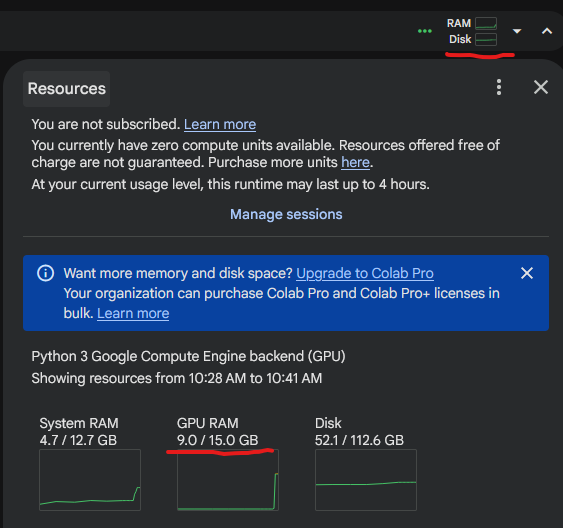

In [9]:
# This will take at least 5 minutes to run
# Take the time to search/google/use AI to understand what each of the variables going into this function do
geoai.train_segmentation_model(
    images_dir=f"{tiles_dir}/images",
    labels_dir=f"{tiles_dir}/masks",
    output_dir=f"{tiles_dir}/unet_models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=6,
    num_classes=2,
    batch_size=8,
    num_epochs=3,
    learning_rate=0.001,
    val_split=0.2,
    verbose=True,
)

print('Training complete!')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Training complete!


**Q2**: Explain why using U-Net and ResNet34 together is a good choice when working with multi-spectral imagery. Use at least two references in your response.

# Answer:
U-Net and ResNet34 are complementary, and their pairing addresses three distinct requirements of multispectral segmentation.

**Skip connections preserve spatial precision:** Segmentation demands both semantic context, for example, is this water ? and exact boundaries Like, where is the shoreline?. Successive downsampling captures the former but destroys the latter. U-Net's defining feature is its skip connections, which pass high-resolution feature maps directly from each encoder stage to the corresponding decoder stage, fusing abstract spectral context with precise geometric location (Ronneberger et al., 2015). This is what allows narrow features such as rivers to be resolved rather than blurred away.

**Residual connections:**
Extracting hierarchical relationships across six spectral bands, not merely within a single image plane, benefits from a deep encoder, combinations such as the NIR/SWIR contrast that separates water from land are not visible in any one channel. Deep networks conventionally suffer from vanishing gradients, and ResNet34's residual shortcut connections allow gradients to propagate backwards unimpeded, so a 34-layer encoder trains stably rather than degrading (He et al.,2016). This exact pairing, a U-Net with a ResNet-34 backbone, has been applied successfully to segmentation of very high-resolution satellite imagery, reporting around 93% accuracy (Vasavi et al.,2023).

**Transfer learning and computational balance:**
Setting encoder_weights = "imagenet", initialises the encoder with weights pretrained on ImageNet, so it already encodes generic visual primitives: edges, textures, shapes, and needs only to specialise to the target task. This is why a usable model can be trained in minutes on a modest dataset. ResNet34 is well-sized too: expressive enough yet light enough that 512*512*6 tiles fit at batch size 8 on a single T4, where heavier backbones would run out of memory. One caveat is that ImageNet weights are three-channel, so the first convolution must be adapted to six bands, encoders pretrained on satellite data can therefore beat ImageNet initialisation for multispectral work. Performance also remains modest for water segmentation:IoU for prior U-Net, ResNet and DeepLabV3 + models is typically 0.60-0.79, with sensitivity to image quality and resolution a noted limitation (Jonnala et al.,2025).

**References**

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. CVPR 2016, 770–778.

Jonnala, N. S., Siraaj, S., Prastuti, Y., Chinnababu, P., Praveen Babu, B., Bansal, S., Upadhyaya, P., Prakash, K., Faruque, M. R. I., & Al-mugren, K. S. (2025). AER U-Net: attention-enhanced multi-scale residual U-Net structure for water body segmentation using Sentinel-2 satellite images. Scientific Reports, 15, 16099. https://doi.org/10.1038/s41598-025-99322-z

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. MICCAI 2015, 234–241.

Vasavi, S., Somagani, H. S., & Sai, Y. (2023). Classification of buildings from VHR satellite images using ensemble of U-Net and ResNet. The Egyptian Journal of Remote Sensing and Space Sciences, 26(4), 937–953. https://doi.org/10.1016/j.ejrs.2023.11.008


**Q3**: What is the learning_rate and what is the likely effect that reducing it will have on your model?

# Answer:
The learning rate is 0.001, it sets how big a step the optimiser takes each time it updates the weights. After every batch the model works out the gradient of the loss, basically which direction reduces the error and then nudges the weights along that direction. The learning rate is how far it nudges. That makes it one of the most important settings in training, because it decides how strongly the model reacts to each batch.
If you lowered it, progress would be slower. The steps would be smaller, so the model would need more epochs to get to the same loss and with only 3 epochs here, it would probably underfit and do worse than it does now. The upside is that smaller steps are less likely to overshoot a good minimum, so with enough epochs a lower rate can settle into a better result with smoother loss curves.
It cuts both ways, though. Too high and the optimiser overshoots, so the loss bounces around or blows up; too low and training just crawls and wastes time. A common middle ground is learning-rate. That trims the padding, drops the "trapped in a local minimum" quibble, and keeps every substantive point.

This model took me 4 to 6 minutes to run on the GPU. If it is taking you more than that, check that you are not still stuck using a CPU (it will take a LOT longer if on a CPU).

With one line of code, we can now take a look at the model performance:

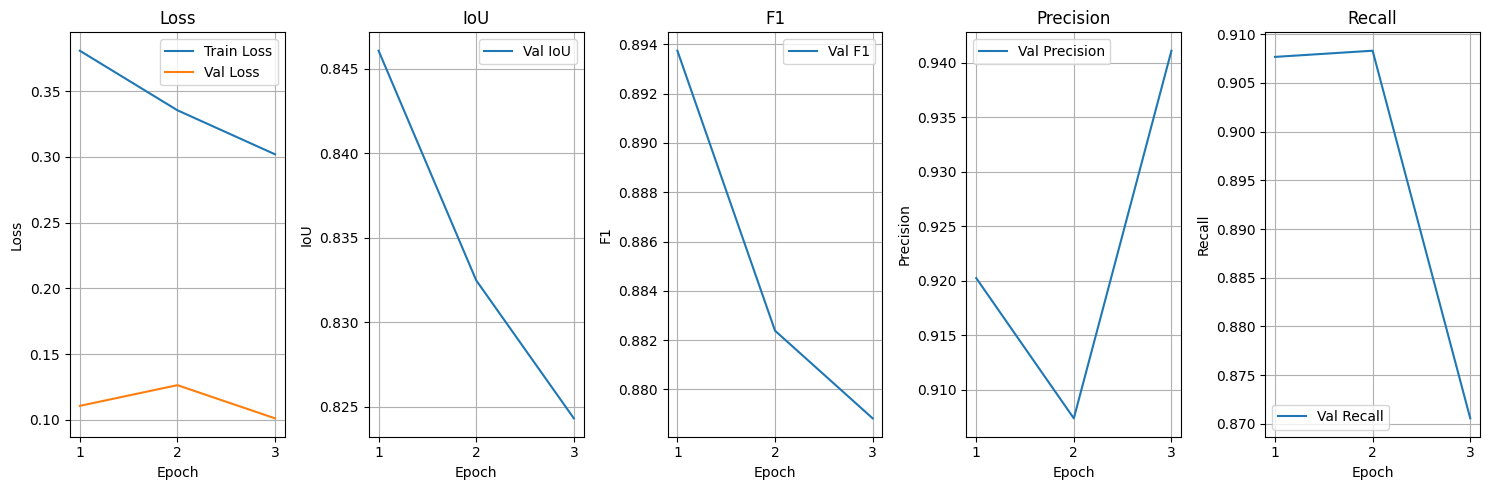

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.380725,0.110722,0.846078,0.893741,0.920256,0.907676
1,2,0.335448,0.126467,0.832479,0.882382,0.907393,0.908311
2,3,0.301970,0.101241,0.824308,0.878825,0.941098,0.870569


In [10]:
# Performance statistics
geoai.plot_performance_metrics(
    history_path=f"{tiles_dir}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

**Q4**: Increase the number of training epochs to 10 (this will take some time, so maybe come back to this question later if need be). Present the resulting graphs of performance metrics in a figure and interpret the results for a technical audience (describe the training that has occured and make reccomendations for future training/use of the model). As always, figures should be of publication quality.

In [11]:
# 10-epoch run
geoai.train_segmentation_model(
    images_dir=f"{tiles_dir}/images",
    labels_dir=f"{tiles_dir}/masks",
    output_dir=f"{tiles_dir}/unet_models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=6,
    num_classes=2,
    batch_size=8,
    num_epochs=10,          # was 3
    learning_rate=0.001,
    val_split=0.2,
    verbose=True,
)

print('Training complete!')

Training complete!


In [12]:
import glob, os

# find every training_history.pth under the tiles dir and report epoch count + age
for p in glob.glob(f"{tiles_dir}/**/training_history.pth", recursive=True):
    try:
        import torch
        h = torch.load(p, map_location="cpu", weights_only=False)
        n = len(h) if isinstance(h, list) else len(next(iter(h.values())))
    except Exception as e:
        n = f"?({e})"
    print(f"{n:>4} epochs   {p}")

  10 epochs   dset-s2/dset-s2/tiles/unet_models/training_history.pth


Available keys: ['train_losses', 'val_losses', 'val_ious', 'val_f1s', 'val_precisions', 'val_recalls']

>>> Epochs in this history: 10


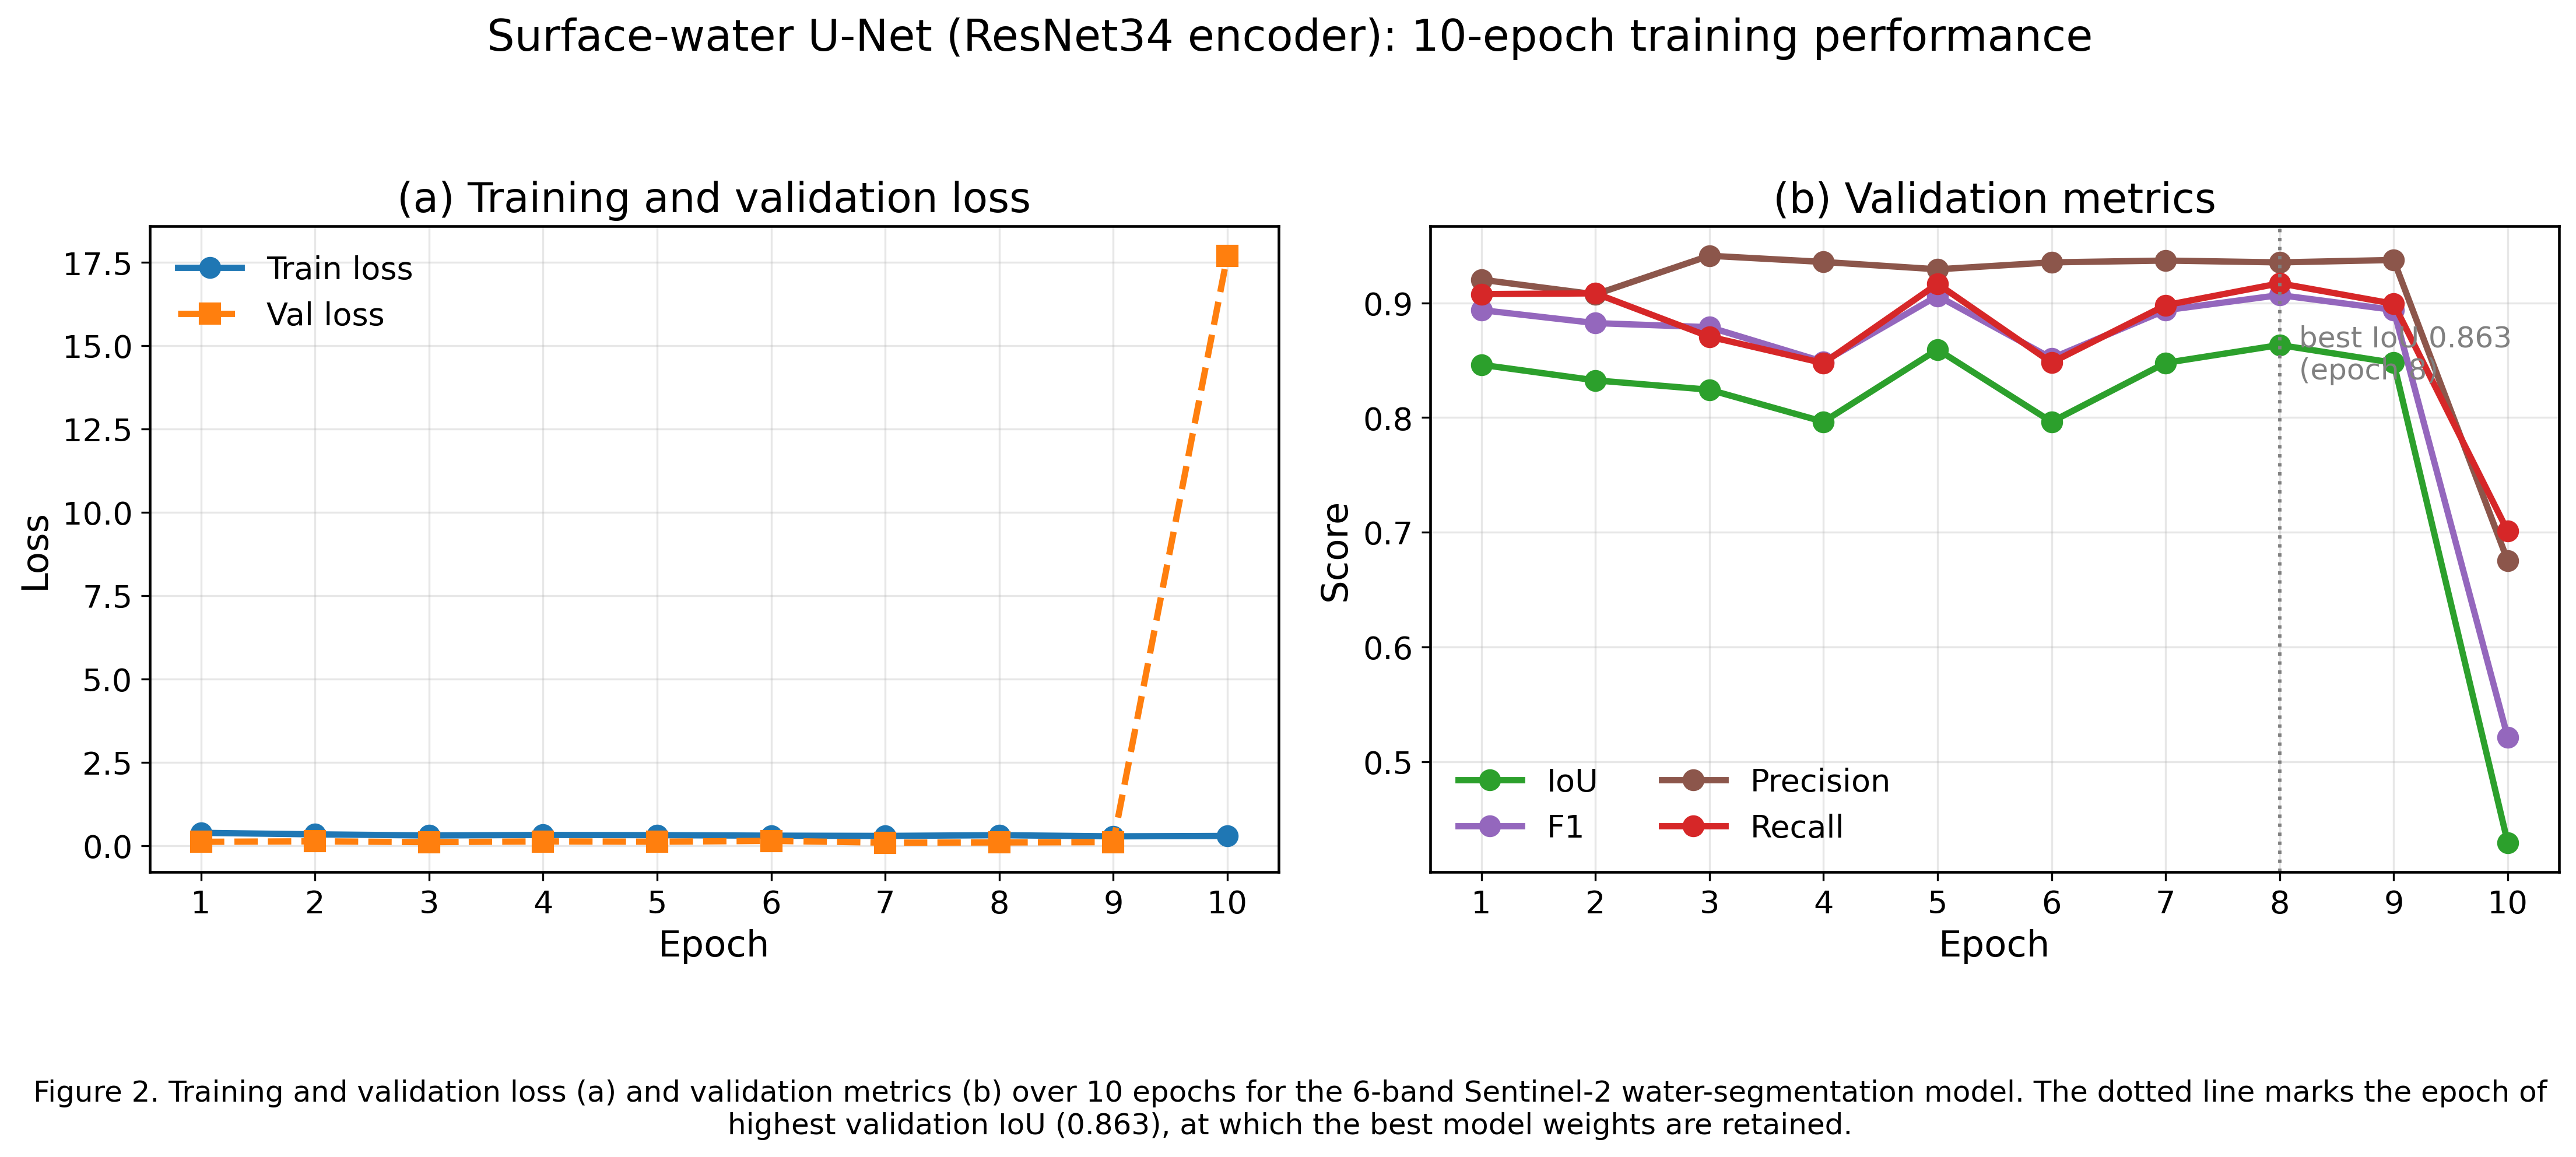


Epochs run:        10
Best val IoU:      0.8633 at epoch 8
Final val IoU:     0.4295
Final train loss:  0.2878 | Final val loss: 17.7033
Min val loss:      0.0854 at epoch 7


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# POINT THIS AT YOUR 10-EPOCH RUN
history_path = f"{tiles_dir}/unet_models/training_history.pth"   # <- change if you used a new dir
hist = torch.load(history_path, map_location="cpu", weights_only=False)

#normalise to a dict of lists, whatever the saved structure
if isinstance(hist, list):
    H = {k: [d[k] for d in hist] for k in hist[0]}
elif isinstance(hist, dict):
    H = hist
else:
    raise TypeError(f"Unexpected history type: {type(hist)}")
print("Available keys:", list(H.keys()))

def col(*names):
    for n in names:
        if n in H:
            return np.asarray(H[n], dtype=float)
    return None

train_loss  = col("train_losses", "loss")
val_loss    = col("val_losses")
val_iou     = col("val_ious", "iou")
val_f1      = col("val_f1s", "f1")
val_prec    = col("val_precisions", "precision")
val_recall  = col("val_recalls", "recall")
epochs      = col("epoch")
if epochs is None:
    epochs = np.arange(1, len(train_loss) + 1)

# SANITY CHECK: is this really the 10-epoch run?
n_ep = len(epochs)
print(f"\n>>> Epochs in this history: {n_ep}")
if n_ep != 10:
    print(f">>> WARNING: expected 10 epochs, found {n_ep}. "
          f"Check `history_path` points at the 10-epoch output directory.")

best_i = int(np.nanargmax(val_iou))

# publication styling
plt.rcParams.update({
    "font.size": 15, "axes.titlesize": 17, "axes.labelsize": 15,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 13,
    "axes.grid": True, "grid.alpha": 0.3, "axes.linewidth": 1.1,
    "figure.dpi": 300, "savefig.dpi": 300,
})
LW, MS = 2.6, 8

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(epochs, train_loss, "o-", color="#1f77b4", lw=LW, ms=MS, label="Train loss")
if val_loss is not None:
    ax1.plot(epochs, val_loss, "s--", color="#ff7f0e", lw=LW, ms=MS, label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("(a) Training and validation loss")
ax1.set_xticks(epochs); ax1.legend(frameon=False)

for y, lab, c in [(val_iou, "IoU", "#2ca02c"), (val_f1, "F1", "#9467bd"),
                  (val_prec, "Precision", "#8c564b"), (val_recall, "Recall", "#d62728")]:
    if y is not None:
        ax2.plot(epochs, y, "o-", color=c, lw=LW, ms=MS, label=lab)
ax2.axvline(epochs[best_i], ls=":", color="grey", lw=1.4)
ax2.annotate(f"best IoU {val_iou[best_i]:.3f}\n(epoch {int(epochs[best_i])})",
             xy=(epochs[best_i], val_iou[best_i]), xytext=(8, -14),
             textcoords="offset points", fontsize=12, color="grey")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.set_title("(b) Validation metrics")
ax2.set_xticks(epochs); ax2.legend(frameon=False, ncol=2)

fig.suptitle(f"Surface-water U-Net (ResNet34 encoder): {n_ep}-epoch training performance",
             fontsize=18, y=1.00)
fig.text(0.5, -0.06,
         f"Figure 2. Training and validation loss (a) and validation metrics (b) over {n_ep} epochs "
         "for the 6-band Sentinel-2 water-segmentation model. The dotted line marks the epoch of "
         f"highest validation IoU ({val_iou[best_i]:.3f}), at which the best model weights are retained.",
         ha="center", fontsize=12, wrap=True)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.savefig("q4_performance.png", dpi=300, bbox_inches="tight")
plt.show()

# numeric summary for the write-up
print(f"\nEpochs run:        {n_ep}")
print(f"Best val IoU:      {val_iou[best_i]:.4f} at epoch {int(epochs[best_i])}")
print(f"Final val IoU:     {val_iou[-1]:.4f}")
if val_loss is not None:
    print(f"Final train loss:  {train_loss[-1]:.4f} | Final val loss: {val_loss[-1]:.4f}")
    print(f"Min val loss:      {val_loss.min():.4f} at epoch {int(epochs[int(np.argmin(val_loss))])}")
else:
    print(f"Final train loss:  {train_loss[-1]:.4f}")

# download
from google.colab import files
files.download("q4_performance.png")

In [14]:
for e, v in zip(epochs, val_loss):
    print(f"epoch {int(e)}: val_loss {v:.4f}")

epoch 1: val_loss 0.1107
epoch 2: val_loss 0.1265
epoch 3: val_loss 0.1012
epoch 4: val_loss 0.1239
epoch 5: val_loss 0.1140
epoch 6: val_loss 0.1401
epoch 7: val_loss 0.0854
epoch 8: val_loss 0.0918
epoch 9: val_loss 0.1015
epoch 10: val_loss 17.7033


In [15]:
for e, iou, f1, p, r in zip(epochs, val_iou, val_f1, val_prec, val_recall):
    print(f"epoch {int(e)}: IoU {iou:.4f}  F1 {f1:.4f}  P {p:.4f}  R {r:.4f}")

epoch 1: IoU 0.8461  F1 0.8937  P 0.9203  R 0.9077
epoch 2: IoU 0.8325  F1 0.8824  P 0.9074  R 0.9083
epoch 3: IoU 0.8243  F1 0.8788  P 0.9411  R 0.8706
epoch 4: IoU 0.7964  F1 0.8487  P 0.9357  R 0.8475
epoch 5: IoU 0.8594  F1 0.9061  P 0.9293  R 0.9166
epoch 6: IoU 0.7964  F1 0.8517  P 0.9353  R 0.8480
epoch 7: IoU 0.8477  F1 0.8936  P 0.9369  R 0.8979
epoch 8: IoU 0.8633  F1 0.9068  P 0.9353  R 0.9171
epoch 9: IoU 0.8478  F1 0.8939  P 0.9374  R 0.8992
epoch 10: IoU 0.4295  F1 0.5213  P 0.6751  R 0.7010


# Answer(Q4)
Extending training from 3 to 10 epochs improved peak performance, but modestly and unreliably. The 3-epoch run's best validation IoU was 0.846(epoch 1), declining thereafter (0.833,0.824); the 10-epoch run reached a peak of **0.863 at epoch 8**,with F1 0.907, precision 0.935 and recall 0.917, and validation loss bottoming at 0.085 (epoch 7). The extra epochs therefore gained roughly 0.017 IoU.

More informative than the peak, however, is the shape of the trajectory. Validation IoU oscillated erratically throughout, 0.846,0.833,0.824,0.796,0.848,0.863,0.848 with two distinct troughs at epochs 4 and 6 and no clear convergence trend. A well-tuned model would settle progressively; this one bounced between roughly 0.80 and 0.86, indicating the fixed 0.001 learning rate was too large for stable refinement and the optimiser was repeatedly overshooting.

That instability culminated at epoch 10, where the model diverged catastrophically: validation loss jumped from **0.1015 to 17.7033**, a 174-fold increase in a single epoch, and IoU collapsed to **0.430**, , while training loss remained low and flat at 0.288. The abruptness rules out overfitting, which produces a gradual climb rather than a single-step jump after nine comparatively stable epochs. It instead indicates a destructive optimiser update: once converged into a narrow minimum, a single batch of large gradients overshot into a degenerate region, precisely the overshoot and diverge failure mode anticipated in Q3. A decaying learning-rate schedule, gradient clipping, or early stopping would prevent it.

The practical lesson is that more epochs improved peak performance, but without a learning-rate schedule the training was neither stable nor reliably convergent, and longer training increased the risk of late-stage failure.

In addition to these performance statistics, we can run [inference](https://www.cloudflare.com/learning/ai/inference-vs-training/) on the validation set to evaluate the model's performance. We will use the semantic_segmentation_batch function to process all the validation images at once.

In [16]:
images_dir = f"{data_dir}/dset-s2/val_scene"
masks_dir = f"{data_dir}/dset-s2/val_truth"
predictions_dir = f"{data_dir}/dset-s2/predictions"
model_path = f"{tiles_dir}/unet_models/best_model.pth"

In [17]:
geoai.semantic_segmentation_batch(
    input_dir=images_dir,
    output_dir=predictions_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=6,
    num_classes=2,
    window_size=512,
    overlap=128,
    batch_size=4,
    quiet=True,
)

And then visualize the results of this!

In [18]:
# Visualize inference outcomes
image_id = "S2A_L2A_20190318_N0211_R061"  # Change to other image id, e.g., S2B_L2A_20190620_N0212_R047
test_image_path = f"{data_dir}/dset-s2/val_scene/{image_id}_6Bands_S2.tif"
ground_truth_path = f"{data_dir}/dset-s2/val_truth/{image_id}_S2_Truth.tif"
prediction_path = f"{data_dir}/dset-s2/predictions/{image_id}_6Bands_S2_mask.tif"
save_path = f"{data_dir}/dset-s2/{image_id}_6Bands_S2_comparison.png"

fig = geoai.plot_prediction_comparison(
    original_image=test_image_path,
    prediction_image=prediction_path,
    ground_truth_image=ground_truth_path,
    titles=["Original", "Prediction", "Ground Truth"],
    figsize=(15, 5),
    save_path=save_path,
    show_plot=True,
    indexes=[5, 4, 3],
    divider=5000,
)

Output hidden; open in https://colab.research.google.com to view.

**Q5**: Discuss the performance of the prediction in our example given above. Do so in reference to the ability of the prediction to resolve key features as compared to the ground truth (e.g. the river vs. the flood ponds). Explain why perfomance is varying in terms of both satellite data physical principles and the limitations of model and its training.

# Answer:
The prediction resolves the two feature types very unevenly. In this scene the river is a narrow, one-to-two-pixel-wide meander while the flood ponds are large contiguous bodies, so the usual expectation that a river is the easier target is inverted here. The broad flood ponds in the upper and central parts of the scene are segmented accurately, their extent and irregular boundaries closely matching the ground truth. The river, by contrast, is only partially recovered: the continuous sinuous channel traced in the ground truth appears in the prediction as a broken, discontinuous line, with long stretches missed entirely. The model reliably captures large water bodies but under-detects the thin linear one.

**Physical principles:**
Water is highly separable in this imagery because it absorbs strongly in the near-infrared and shortwave-infrared bands, appearing very dark against land, visible in the false-colour composite, where both river and ponds read near-black against pinkish terrain. This is why the spectrally unambiguous ponds are segmented well. The river fails for a resolution reason rooted in the same physics: at Sentinel-2's 10m resolution it is only two pixels wide, so most pixels along it are mixed pixels containing both water and blank vegetation. Their averaged reflectance is a blend rather than the clean dark water signature, so model confidence drops below threshold and channel fragments.

**Model and training limitations:**
Three things compound the physical problem. Water makes up a small fraction of that water, so the loss is dominated by land and by the large ponds, the model has little incentive to chase a pixel-sparse channel. This also explains the gap between the metrics and what you see: IoU is area-weighted, so missing a One-pixel-wide river barely dents the score, even though it is an obvious failure by eye. The model never really converged. Validation IoU swung between 0.796 and 0.863 across epochs rather than settling, so the saved weights are just the best-scoring epoch, not a stable optimum, which means how it handles marginal features like the river is partly luck and would diffeer from run to run. Fixing this needs finer resolution, a loss that rewards connectivity or boundaries, or up-weighting thin features not simply more epochs.

Hopefully you can now see the difference that GeoAI makes to your workflow as compared to what we have gone through in the other labs.

Their library is doing a lot of the plumbing and model management for you behind the scenes, allowing you to write faster and solve different problems rather than getting stuck in the weeds. We have only imported one library to accomplish something that before we were using 5 or 6 to do. This does come with drawbacks, choices have been made for you- but particuarly for quick prototyping this is a strong advantage.

Note that the GeoAI tutorial also shows you [how to gather satellite data](https://opengeoai.org/workshops/TNView_2025/#download-sentinel-2-imagery) from a [STAC catalgoue](https://stacspec.org/en). This is the alternative (to the GEE approach used to date) way to build satellite data stacks for use in your project. Might well be useful for you in your projects...

# Task 2: Detecting solar panels from aerial imagery
In Task 1 we used semantic segmentation to classify pixels in satellite imagery. In this task we use a similar deep-learning workflow to identify solar panels in high-resolution aerial imagery, but then move from pixels to individual mapped objects.

The important distinction is that the U-Net produces a pixel-level segmentation. We will then convert that segmentation into polygons and use the geometry of those polygons to remove some of the small or implausible detections. This gives us a simple object-level workflow without introducing a separate object-detection model.

Before starting this task, clear the cache and make sure your RAM is empty from Task 1, or you may crash the Colab instance.

We will work with a labelled training image and vector dataset from Davis, California, and a separate aerial image for testing. The data are provided through [Hugging Face](https://huggingface.co/).

First, we will clear the data and model from Task 1 from our memory. You always want to make sure that a fresh model run has a clean memory to use, as otherwise these free instances will very quickly beocome jammed up and crash:

In [19]:
# Clear memory before starting Task 2
import gc

# Python garbage collection
gc.collect()

# Clear PyTorch GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Report current GPU memory
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3

    print("Memory cleared.")
    print(f"GPU memory allocated: {allocated:.2f} GB")
    print(f"GPU memory reserved:  {reserved:.2f} GB")
else:
    print("Memory cleared. No CUDA GPU detected.")

Memory cleared.
GPU memory allocated: 0.00 GB
GPU memory reserved:  0.00 GB


Next, we specify our data sources and then download them:

In [20]:
# Set the URLS that you are getting the data from
train_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.tif"
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.geojson"
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_test_davis_ca.tif"

In [21]:
# Use GeoAI to download them
train_raster_path = geoai.download_file(train_raster_url)
train_vector_path = geoai.download_file(train_vector_url)
test_raster_path = geoai.download_file(test_raster_url)

Let's take a look at it using our own interactive view tool.

In [22]:
show_interactive(raster=train_raster_path, vector=train_vector_path, title="Training scene")

Output hidden; open in https://colab.research.google.com to view.

Q6: Examine the training image and labelled polygons. What visual characteristics distinguish the solar panels from the surrounding roofs, roads and vegetation? Identify at least two characteristics that a convolutional neural network could potentially learn from the imagery.

# **Answer:**
In this aerial imagery, solar panels are visually distinct in two main ways. They appear as saturated blue to blue-grey rectangles, noticeably bluer than the surrounding terracotta and grey roofs, asphalt and vegetation, giving a consistent colour signature, and they have regular geometry: sharp, straight edges forming rectangular modules, usually clustered into parallel arrays sharing one orientation on a roof plane, unlike the irregular outlines of vegetation or the varied shapes of ordinary roofs. The main confusers are dark or bluish roofs, roof shadows, and swimming pools, which match the blue tone but lacks the sharp module edges.

A CNN can exploit both: the uniform blue-grey RGB reflectance, and the rectangular geometry with high-contrast edges and repeating array pattern, which convolutional filters capture well as local edge and texture features. In task 1 Water was separable in the spectrum due to NIR/SWIR absorption. In contrast, here only RGB is available, and the resolution is finer, so geometry has to carry much of the discrimination.

We now convert the labelled image into image/label tiles for training.

A 512 × 512 tile is large enough to contain complete solar-panel objects while still being manageable on a Colab GPU. The stride controls how much neighbouring tiles overlap.

In [23]:
out_folder = "solar"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)

Generating tiles:   0%|          | 0/312 [00:00<?, ?it/s]

Train a U-Net segmentation model. As in Task 1, the model predicts a class for each pixel. Here the two classes are background and solar panel. This took me 3-5 minutes to train on the GPU. On the CPU it took over 30 minutes:

In [24]:
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=8,
    num_epochs=10,
    learning_rate=1e-3,
    val_split=0.2,
)

Evaluate the model:

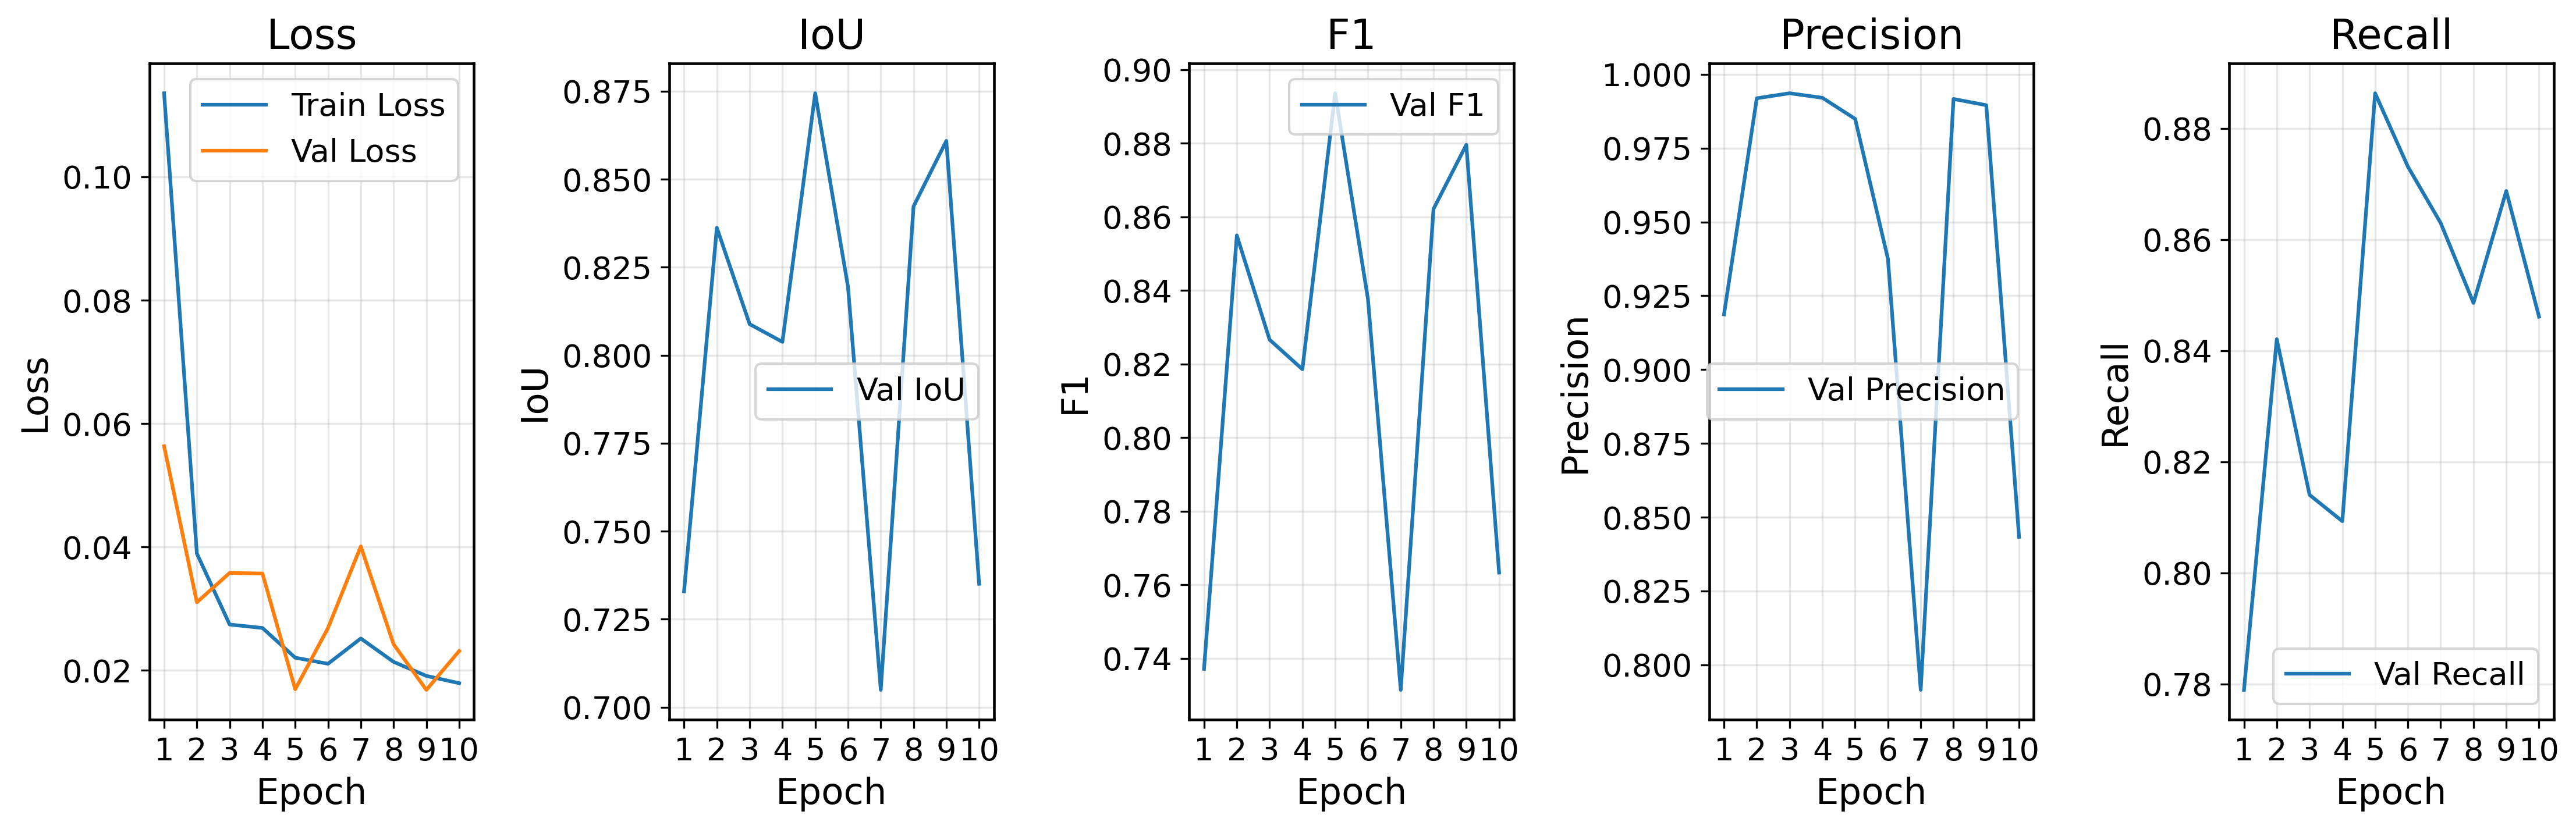

,epoch,train_loss,val_loss,val_iou,val_f1,val_precision,val_recall
0,1,0.113537,0.056339,0.732907,0.737127,0.918707,0.778934
1,2,0.038952,0.031043,0.836218,0.854932,0.991904,0.842063
2,3,0.027443,0.035810,0.808828,0.826580,0.993605,0.814043
3,4,0.026885,0.035708,0.803781,0.818550,0.992067,0.809296
4,5,0.022069,0.016952,0.874434,0.893559,0.984924,0.886337
5,6,0.021084,0.026880,0.819462,0.837623,0.937523,0.873128
6,7,0.025183,0.040112,0.704899,0.731410,0.791513,0.862976
7,8,0.021394,0.024247,0.842292,0.862113,0.991668,0.848587
8,9,0.019119,0.016850,0.860899,0.879543,0.989555,0.868744
9,10,0.017936,0.023146,0.735039,0.763284,0.843346,0.846109


In [25]:
geoai.plot_performance_metrics(
    history_path=f"{out_folder}/models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

Q7: Examine the training and validation curves. Is there evidence that the model is still learning, or that it is beginning to overfit? What would you change about the training process if you wanted to improve the model further?

Now apply the trained model to the unseen test image. In addition to the usual class mask, we will save the model's probability map. For a two-class problem, the second band contains the probability that each pixel belongs to the solar-panel class.

This is useful because the default mask hides how confident the model was. A pixel just above the classification boundary is different from a pixel for which the model is highly confident.

# Answer:
The curves show no classic overfitting, but not clean convergence either. Training loss falls steadily (0.114 leads to 0.018), while validation loss does not track it. It bounces between 0.017 and 0.056 with no sustained upward trend, so the picture is noisy non-convergence rather than overfitting. Validation IoU peaks at 0.874 (epoch 5) but ends at 0.735, so the last epoch is not the best one.
Two things stand out. The metrics oscillate a lot, and the dip epochs (7 and 10) are precision collapses (0.79,0.84) while recall holds, so the instability shows up as sudden bursts of false positives, not gradual drift. That looks like the optimiser overshooting at the fixed 0.001 learning rate, and a schedule or early stopping would settle it. The bigger pattern is the gap between precision (0.98-0.99) and recall (0.78-0.89): the model is conservative, rarely flagging a non-panel but missing about 11% of real panel pixels at best, up to 22% at worst. That is the class imbalance showing, only 137 of 312 tiles contain panels, so the model leans toward the majority background class.
To fix it I would add a learning-rate schedule or early stopping to kill the late precision collapses, and tackle the imbalance to lift recall, a Dice or Tversky loss, class weighting, or oversampling the 137 panel tiles, So it captures more panels without sacrificing its precision.



In [26]:
masks_path = "solar_panels_prediction.tif"
probability_path = "solar_panels_probability.tif"
model_path = f"{out_folder}/models/best_model.pth"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=masks_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_path=probability_path,
)

  0%|          | 0/209 [00:00<?, ?it/s]

Let's look at both the predicted mask.

In [27]:
show_interactive(raster=test_raster_path, mask=masks_path, probability=probability_path, title="Predictions")

Output hidden; open in https://colab.research.google.com to view.

Confident detections (peak prob >=0.8): 27
Marginal detections  (peak prob <0.8):  24


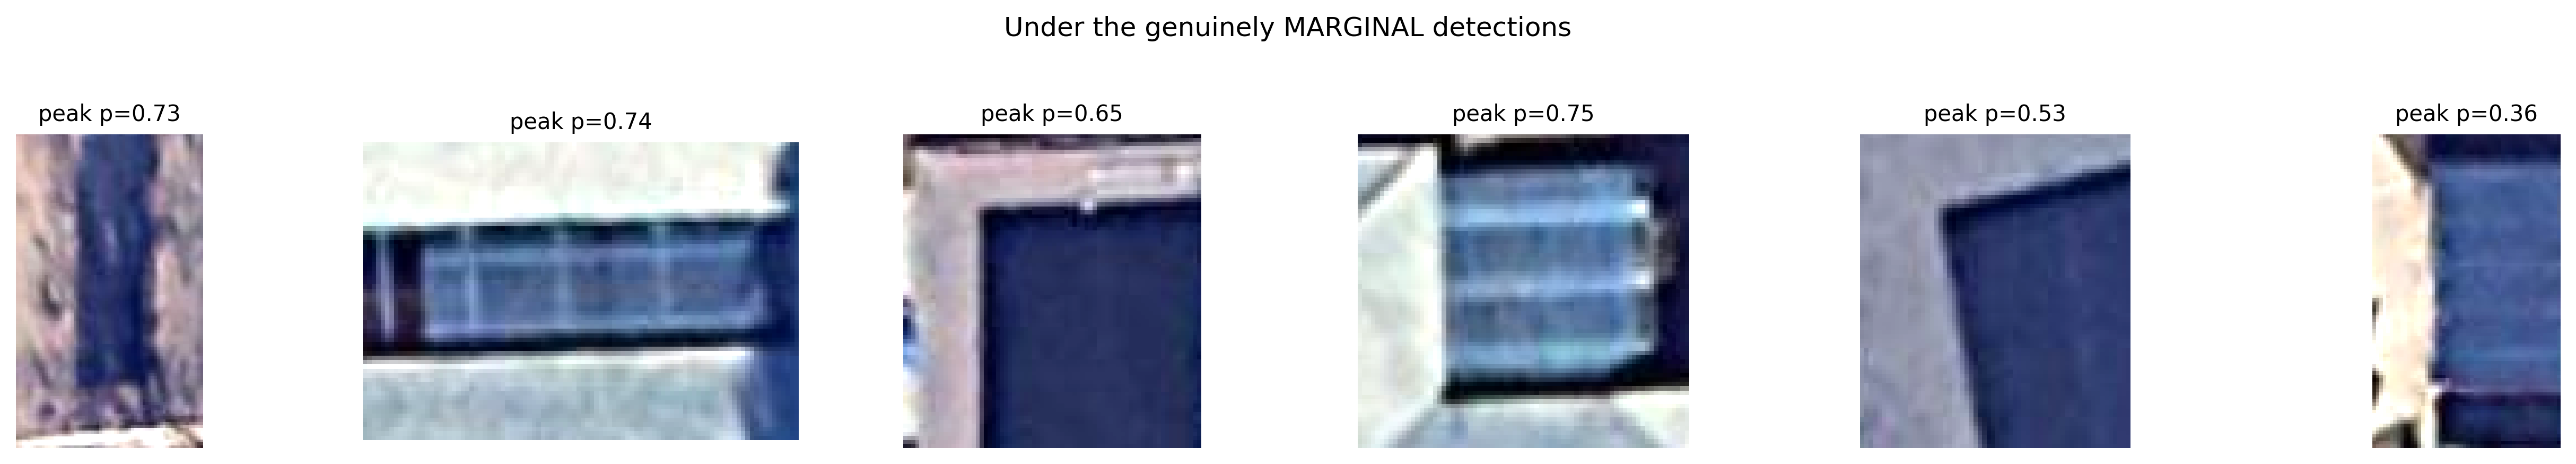

In [28]:
#check to confirm the answer 8
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

# rebuild prob and rgb (lost when the runtime reset)
with rasterio.open(probability_path) as src:
    prob = src.read(2).astype("float32")
    if np.nanmax(prob) > 1.5:
        prob = prob / (255.0 if np.nanmax(prob) > 100 else 100.0)

with rasterio.open(test_raster_path) as src:
    rgb = np.transpose(src.read([1, 2, 3]), (1, 2, 0)).astype("float32")
    rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1)

detected = prob > 0.3
lbl = label(detected)
conf_regions, marg_regions = [], []
for r in regionprops(lbl, intensity_image=prob):
    if r.max_intensity >= 0.8:
        conf_regions.append(r)
    else:
        marg_regions.append(r)

print(f"Confident detections (peak prob >=0.8): {len(conf_regions)}")
print(f"Marginal detections  (peak prob <0.8):  {len(marg_regions)}")

# show the MARGINAL ones this time — those are the ones that reveal confusers
import matplotlib.pyplot as plt, numpy as np
n = min(6, len(marg_regions))
if n:
    fig, ax = plt.subplots(1, n, figsize=(3*n, 3)); ax = np.atleast_1d(ax)
    for a, r in zip(ax, sorted(marg_regions, key=lambda x: -x.area)[:n]):
        y0, x0, y1, x1 = r.bbox; pad = 20
        y0, x0 = max(0, y0-pad), max(0, x0-pad)
        y1, x1 = min(rgb.shape[0], y1+pad), min(rgb.shape[1], x1+pad)
        a.imshow(rgb[y0:y1, x0:x1]); a.set_title(f"peak p={r.max_intensity:.2f}", fontsize=10); a.axis("off")
    fig.suptitle("Under the genuinely MARGINAL detections", fontsize=12); plt.tight_layout(); plt.show()
else:
    print("No detections with peak prob < 0.8 — the model is confident on essentially all its detections.")

Q8: Compare the binary mask with the probability map. Where does the model appear confident? Where does it appear uncertain? Why might a probability map be more useful than a binary mask when deciding how to improve a detection workflow?

# Answer:
The binary mask records only the model's hard decision at the 0.5 boundary, so a pixel that barely crossed the threshold looks identical to one the model was certain about. The probability map preserves that confidence, and inspecting it reveals a clear structure. Sampling the detection shows 27 high-confidence objects (peak probability >= 0.8 up to 1.0) sitting squarely on clear rooftop arrays, the model is decisively certain about well-defined panels. The remaining 24 detections are genuinely marginal (peak probability 0.36-0.75), and crops of the imagery beneath them confirm these are still real solar panels, but the harder ones: darker, lower-contrast arrays, smaller installations, and panels at oblique angles where the visual signal is weaker. The uncertainty is therefore concentrated on faint true panels rather than on false detections.

This makes the probability map a more useful output. It shows not just where panels are but how confident the model is, and here it localises the weakness precisely, dim, small or angled panels, which the binary mask hides entirely. It also makes the choice of decision threshold meaningful rather than fixed at 0.5: because the marginal objects are real panels, raising the threshold discards genuine detections and lowers recall, while lowering it recovers faint panels at some risk of false positives. The binary mask, by collapsing everything to 0/1, throws away exactly the information needed to make that trade-off.

Improving the segmentation with a probability threshold:

The default binary result uses the model's class decision. We can instead specify a probability threshold for the solar-panel class. A lower threshold will normally retain more candidate pixels, while a higher threshold will normally produce fewer, more conservative detections.

Run the model again using a threshold of 0.7. Then compare this result with the original prediction.

In [29]:
threshold = 0.7
threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=threshold_mask_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_threshold=threshold,
)

show_interactive(raster=test_raster_path, mask=threshold_mask_path,
                 probability=probability_path, title=f"Predictions (threshold {threshold})")

Output hidden; open in https://colab.research.google.com to view.

In [30]:
import rasterio, numpy as np
from skimage.measure import label

def count_objects(path):
    with rasterio.open(path) as src:
        m = src.read(1) > 0
    return label(m).max(), int(m.sum())

n05, px05 = count_objects(masks_path)          # original (0.5)
n07, px07 = count_objects(threshold_mask_path) # 0.7

print(f"Original (0.5):  {n05} objects, {px05:,} panel pixels")
print(f"Threshold 0.7:   {n07} objects, {px07:,} panel pixels")
print(f"Removed by 0.7:  {n05-n07} objects, {px05-px07:,} pixels "
      f"({100*(px05-px07)/px05:.0f}% of panel pixels)")

Original (0.5):  38 objects, 110,996 panel pixels
Threshold 0.7:   37 objects, 89,466 panel pixels
Removed by 0.7:  1 objects, 21,530 pixels (19% of panel pixels)


Q9: Experiment with at least two different probability thresholds between 0.3 and 0.9. Compare the resulting masks visually. Which threshold gives you the most useful balance between retaining solar-panel pixels and rejecting false positives? Explain your choice using evidence from the imagery.

In [31]:
import rasterio, numpy as np
from skimage.measure import label

def stats(path):
    with rasterio.open(path) as src:
        m = src.read(1) > 0
    return int(label(m).max()), int(m.sum())

results = {}
for thr in [0.3, 0.5, 0.7, 0.9]:
    if thr == 0.5:
        p = masks_path
    else:
        p = f"solar_panels_prediction_{thr:.1f}.tif"
        geoai.semantic_segmentation(
            input_path=test_raster_path, output_path=p, model_path=model_path,
            architecture="unet", encoder_name="resnet34", num_channels=3,
            num_classes=2, window_size=512, overlap=256, batch_size=8,
            probability_threshold=thr)
    n, px = stats(p)
    results[thr] = (n, px)

print(f"{'Threshold':>10} {'Objects':>8} {'Panel px':>10} {'Mean px/obj':>12}")
for thr,(n,px) in results.items():
    print(f"{thr:>10.1f} {n:>8} {px:>10,} {px/n:>12,.0f}")

  0%|          | 0/209 [00:00<?, ?it/s]

  0%|          | 0/209 [00:00<?, ?it/s]

  0%|          | 0/209 [00:00<?, ?it/s]

 Threshold  Objects   Panel px  Mean px/obj
       0.3       51    135,304        2,653
       0.5       38    110,996        2,921
       0.7       37     89,466        2,418
       0.9       28     61,834        2,208


Regions lost between 0.3 and 0.5: 74
Their sizes (px): [np.float64(1577.0), np.float64(1511.0), np.float64(1414.0), np.float64(1400.0), np.float64(1389.0), np.float64(1165.0), np.float64(970.0), np.float64(794.0), np.float64(770.0), np.float64(686.0), np.float64(673.0), np.float64(672.0), np.float64(665.0), np.float64(605.0), np.float64(583.0), np.float64(563.0), np.float64(527.0), np.float64(522.0), np.float64(498.0), np.float64(490.0), np.float64(463.0), np.float64(409.0), np.float64(390.0), np.float64(372.0), np.float64(365.0), np.float64(348.0), np.float64(337.0), np.float64(337.0), np.float64(316.0), np.float64(254.0), np.float64(250.0), np.float64(232.0), np.float64(209.0), np.float64(205.0), np.float64(173.0), np.float64(159.0), np.float64(147.0), np.float64(146.0), np.float64(141.0), np.float64(136.0), np.float64(130.0), np.float64(129.0), np.float64(127.0), np.float64(120.0), np.float64(114.0), np.float64(104.0), np.float64(103.0), np.float64(92.0), np.float64(72.0), np.float6

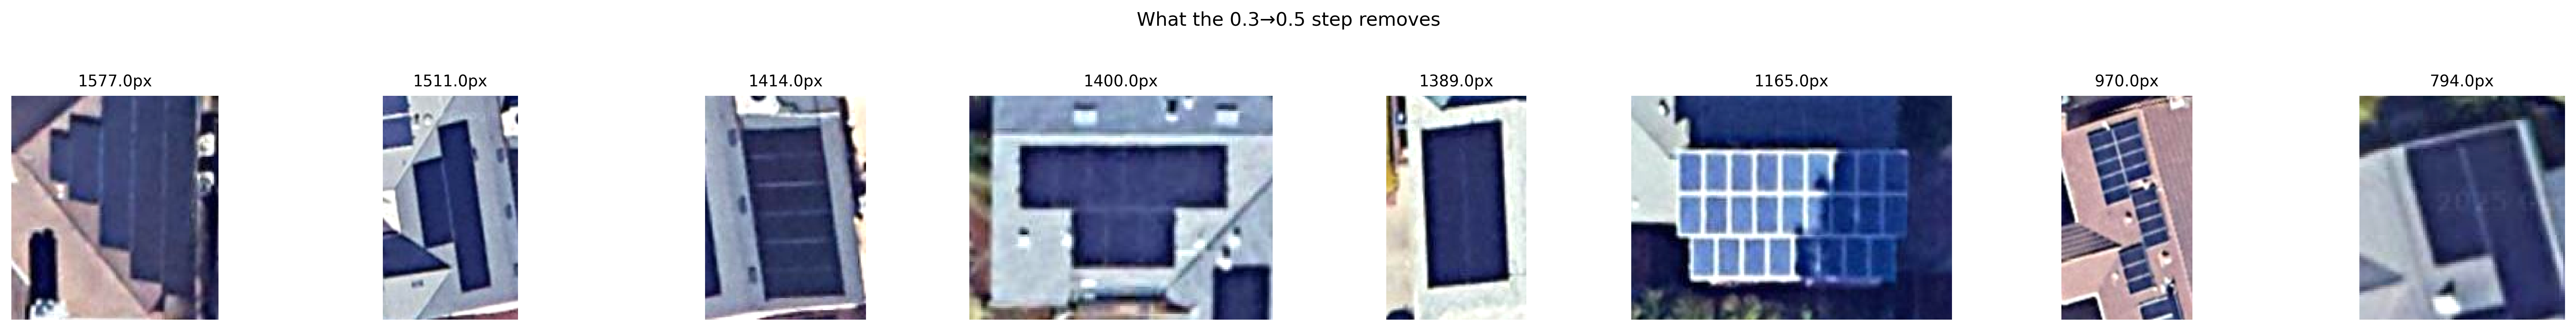

In [32]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from skimage.measure import label, regionprops

with rasterio.open(test_raster_path) as src:
    rgb = np.transpose(src.read([1,2,3]),(1,2,0)).astype("float32")
    rgb = np.clip(rgb/np.percentile(rgb,98),0,1)

m03 = rasterio.open("solar_panels_prediction_0.3.tif").read(1) > 0
m05 = rasterio.open(masks_path).read(1) > 0
lost = m03 & ~m05                      # detected at 0.3, gone at 0.5

lbl = label(lost)
regs = sorted(regionprops(lbl), key=lambda r:-r.area)
print(f"Regions lost between 0.3 and 0.5: {lbl.max()}")
print(f"Their sizes (px): {[r.area for r in regs]}")

n = min(8, len(regs))
fig, ax = plt.subplots(1,n,figsize=(3*n,3)); ax=np.atleast_1d(ax)
for a,r in zip(ax,regs[:n]):
    y0,x0,y1,x1=r.bbox; pad=25
    y0,x0=max(0,y0-pad),max(0,x0-pad)
    y1,x1=min(rgb.shape[0],y1+pad),min(rgb.shape[1],x1+pad)
    a.imshow(rgb[y0:y1,x0:x1]); a.set_title(f"{r.area}px",fontsize=10); a.axis("off")
fig.suptitle("What the 0.3→0.5 step removes",fontsize=12); plt.tight_layout(); plt.show()

# Answer:
I compared the segmentation at four probability thresholds, tracking objects, total panel pixels, and mean object size.

The total number of panel pixels decreases monotonically as the threshold rises. Inspecting what is lost at each step shows the trade-off is a recall cost throughout, not noise removal. Crops of the regions dropped between 0.3 and 0.5 are all real solar panel arrays, several of them large (1400-1600 px), that happen to be darker or lower-contrast, so their predicted probability sits between 0.3 and 0.5; these are exactly the faint-but-real panels identified in Q8. Above 0.5, the object count is nearly flat (38 down to 37 by 0.7) while mean size keeps falling, the signature of erosion, surviving panels are shaved at their low-confidence edges, until by 0.9, whole faint panels vanish (28 objects). The mean size rises from 0.3 to 0.5, reflecting fragmentation cleanup (0.3 splits panels into many small pieces that consolidate at 0.5), but the high-area losses at that step are genuine panels, not clutter.
There is therefore no threshold that removes false detections without also removing true panels, consistent with Q7 (the model is recall-limited) and Q8 (its uncertain detections are real faint panels). The best choice depends on the downstream goal. The best choice depends on the downstream goal. The best choice depends on the downstream goal. For maximum recall, mapping as many panels as possible, a lower threshold (0.3 or 0.5) is preferable, accepting some fragmentation. 0.5 is the better default: it consolidates the fragmentation of 0.3 into cleaner objects while losing relatively few whole panels, and its output feeds the object-level workflow more tidily. Higher thresholds (0.7, 0.9) should be avoided here, since they erode and delete real panels. The 19% pixel loss from 0.5 to 0.7, with almost no drop in object count, is genuine panel area, not false positives. (Object counts are connected-component counts under 1-connectivity, so they slightly over-count physical installations and should be read as a relative trend.)  

From pixels to objects:

The segmentation is still a raster. For many mapping applications we want individual features that can be counted, measured and filtered. We therefore convert the selected mask to polygons and regularise the polygon shapes.

In [33]:
output_path = "solar_panels_prediction.geojson"
gdf = geoai.orthogonalize(threshold_mask_path, output_path, epsilon=2)

print(f"Number of polygons before filtering: {len(gdf)}")

Converting features:   0%|          | 0/38 [00:00<?, ?shape/s]

Number of polygons before filtering: 37


We can now calculate geometric properties for every predicted object. This gives us information such as area, perimeter and shape characteristics that were not available in the raster mask.

In [34]:
gdf_props = geoai.add_geometric_properties(
    gdf,
    area_unit="m2",
    length_unit="m",
)

print(gdf_props[["area_m2", "length_m", "elongation", "solidity"]].describe())

         area_m2   length_m  elongation   solidity
count  37.000000  37.000000   37.000000  37.000000
mean   13.474234  14.013817    1.741769   0.935216
std    17.989089  11.687319    0.625891   0.039759
min     0.005572   0.298596    1.000036   0.809176
25%     1.253806   4.926819    1.375050   0.917197
50%     4.764463  11.943724    1.565520   0.942170
75%    18.277704  20.603049    2.000073   0.960187
max    67.577353  45.087683    3.761510   1.000000


Inspect the distribution of object sizes and shapes, then apply a simple geometric filter. Solar panels are relatively compact, regular objects, whereas tiny isolated detections are often artefacts of the segmentation.

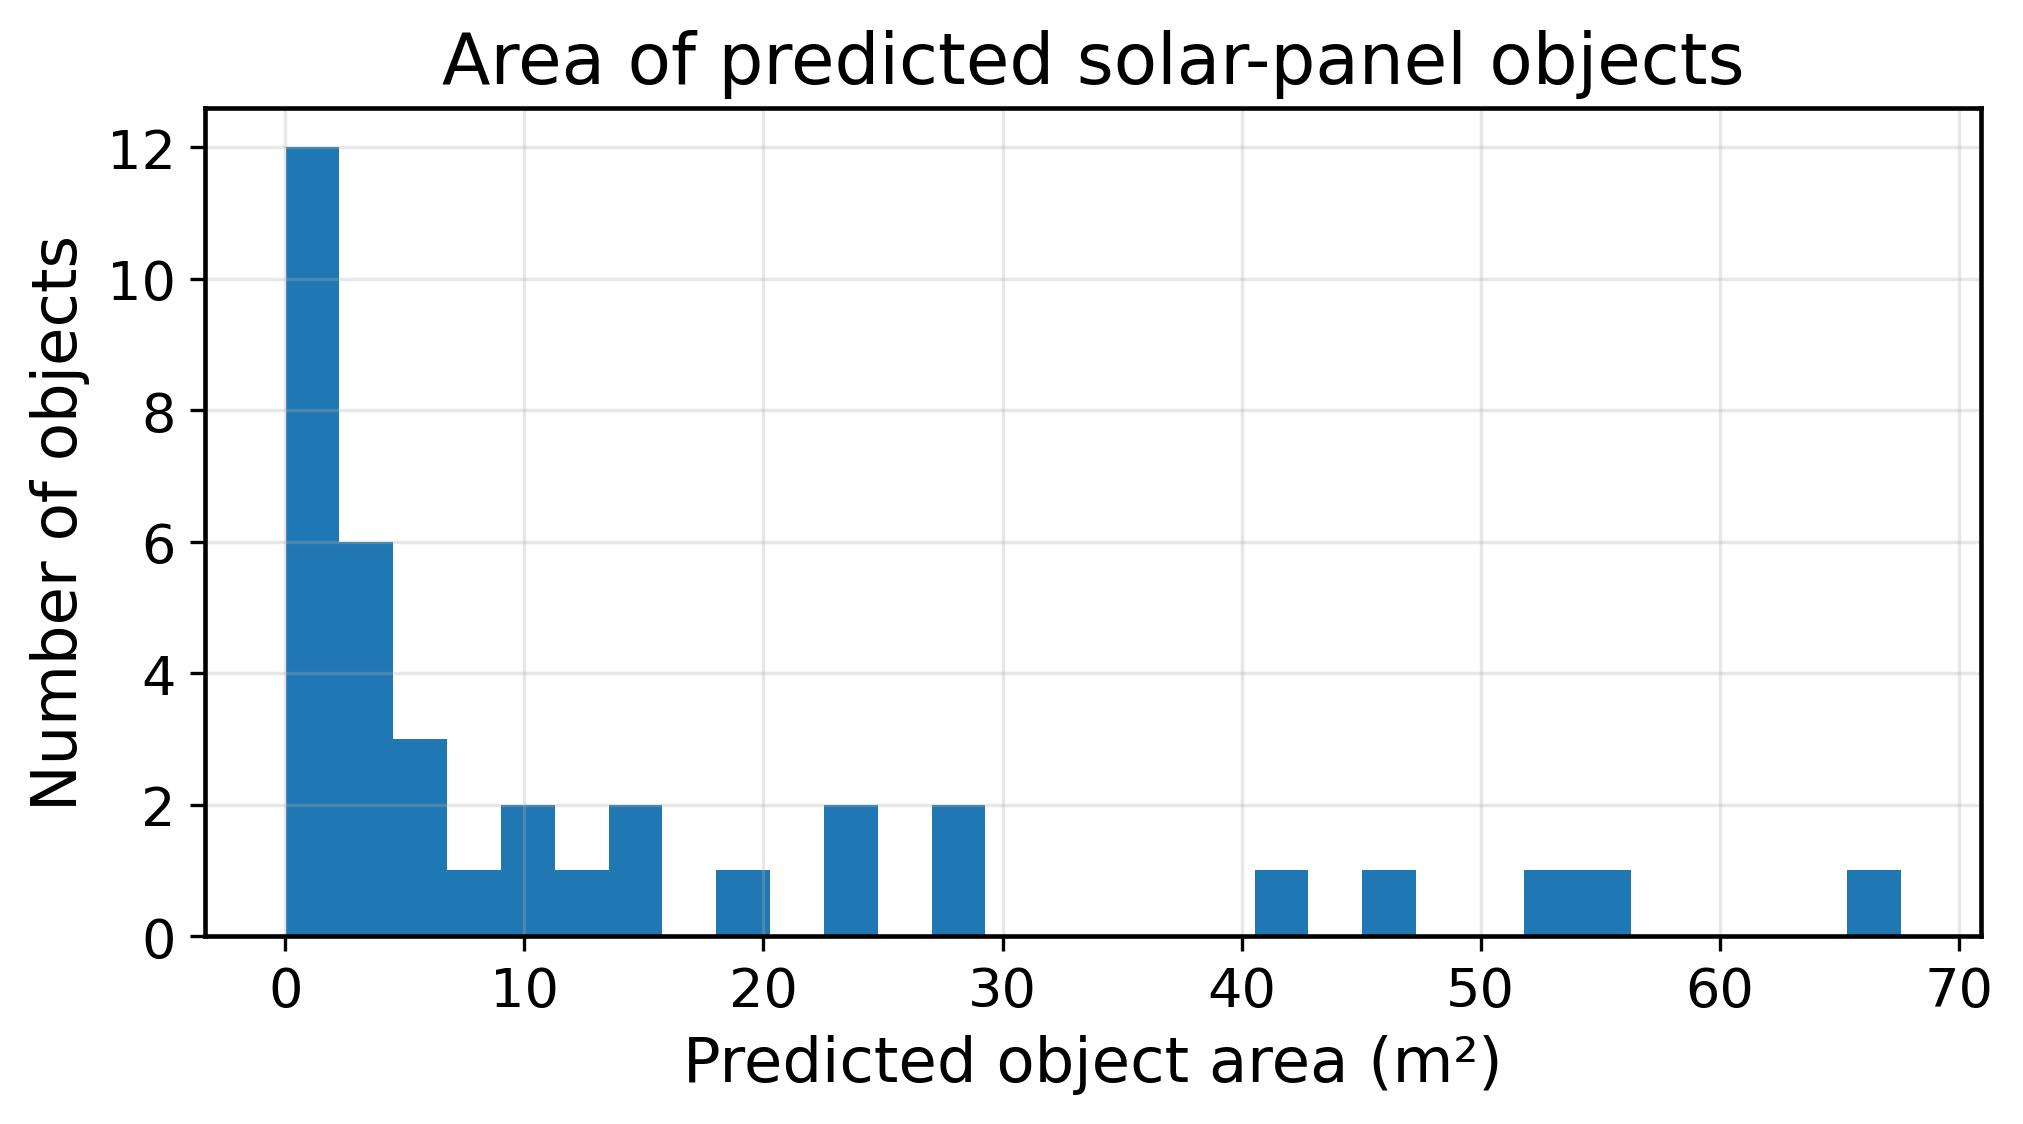

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
gdf_props["area_m2"].hist(bins=30, ax=ax)
ax.set_xlabel("Predicted object area (m²)")
ax.set_ylabel("Number of objects")
ax.set_title("Area of predicted solar-panel objects")
plt.tight_layout()
plt.show()

In [36]:
print("Vectorised from:", output_path)
print("Polygon count:", len(gdf))
# which mask? check the cell you ran — was it masks_path (0.5) or threshold_mask_path (0.7)?
import rasterio, numpy as np
from skimage.measure import label
for name, p in [("0.5", masks_path), ("0.7", threshold_mask_path)]:
    with rasterio.open(p) as src:
        print(f"{name} mask objects:", label(src.read(1) > 0).max())

Vectorised from: solar_panels_prediction.geojson
Polygon count: 37
0.5 mask objects: 38
0.7 mask objects: 37


Q10: Based on the area distribution and the map, choose a minimum object area that removes obvious small artefacts without removing genuine solar panels. State the threshold you chose and explain the trade-off.

# Answer:
The area distribution in cell is heavily right-skewed with no clean gap. About a dozen objects pile up in the smallest bin, then the counts taper off smoothly to a few large arrays, the largest around 67 m². The median is only 4.8 m², and the smallest object is 0.006 m². Since there is no natural break to cut at, I based the threshold on what is physically possible rather than a gap that is not there. A single solar panel is roughly 1.6 m², and real installations are several panels together, so anything under about 1.5 m² can't be a genuine panel; it is a vectorisation speck or an encoded silver. I set min_area = 1.5 m², which removed 10 of the 37 objects and left 27. The ten that went run from 0.006 to 1.25 m², all well below one panel, so the filter only took fragments.

I kept the cut low on purpose. These objects came from 0.7 mask, which Q9 showed erodes panels at their edges, and the model is recall-limited anyway (Q7: precision 0.98-0.99 but recall only 0.78-0.89, with Q8 confirming its faint detections are real panels). A more aggressive cut would just drop small or partly-detected real panels. The geometry supports a low threshold too: median solidity is 0.94, so the objects are compact and panel-shaped rather than stringy noise. Filtering on elongation and solidity as well could target thin false positives, but for this scene area alone clears out the implausible specks.
A notable convergence: the 27 objects left after filtering match the 27 high-confidence detections from the model, which makes sense; where the model is unsure, the object it produces tends to be small, so the faint detections and the tiny fragments are largely the same things.

Note: I have left the vector display as the default settings and they are a little hard to see... you may want to go and expand the code cell at the top of the lab that does the 'show_interactive' and see if you can make it better...

In [37]:
# Change this value after inspecting the area distribution and map.
min_area = 1.5

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

Objects before filtering: 37
Objects after filtering:  27
Objects removed:          10


In [38]:
# do the area-surviving objects coincide with the high-confidence ones?
import numpy as np
print("Area-filtered objects:", len(gdf_filtered))
print("Their area range:", f"{gdf_filtered['area_m2'].min():.2f}–{gdf_filtered['area_m2'].max():.2f} m²")
# how many removed objects were small AND low-confidence vs small but real?
removed = gdf_props[gdf_props["area_m2"] < 1.5]
print("Removed (area<1.5):", len(removed), "| their sizes:", sorted(removed["area_m2"].round(3).tolist()))

Area-filtered objects: 27
Their area range: 1.52–67.58 m²
Removed (area<1.5): 10 | their sizes: [0.006, 0.011, 0.039, 0.128, 0.145, 0.24, 0.401, 0.775, 0.797, 1.254]


In [39]:
show_interactive(raster=test_raster_path, vector=gdf_filtered, vector_column="area_m2", title="Filtered detections")

Output hidden; open in https://colab.research.google.com to view.

In [40]:
#for Q11, it will show all 27 detections and we can than pick two good and two failed ones
import rasterio, numpy as np, matplotlib.pyplot as plt
from rasterio.plot import plotting_extent

with rasterio.open(test_raster_path) as src:
    rgb = np.transpose(src.read([1,2,3]), (1,2,0)).astype("float32")
    rgb = np.clip(rgb/np.percentile(rgb,98), 0, 1)
    extent = plotting_extent(src)
    gdf_plot = gdf_filtered.to_crs(src.crs)

fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(rgb, extent=extent)
gdf_plot.plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=2)
for _, r in gdf_plot.iterrows():
    c = r.geometry.centroid
    ax.annotate(f"{r.area_m2:.0f}", (c.x, c.y), color="cyan", fontsize=8,
                ha="center", va="center", weight="bold")
ax.set_title("Filtered solar-panel detections (area in m²)", fontsize=14)
ax.axis("off")
plt.tight_layout(); plt.savefig("q11_detections.png", dpi=200, bbox_inches="tight"); plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [41]:
import rasterio, numpy as np, matplotlib.pyplot as plt
from rasterio.plot import plotting_extent

with rasterio.open(test_raster_path) as src:
    rgb = np.transpose(src.read([1,2,3]),(1,2,0)).astype("float32")
    rgb = np.clip(rgb/np.percentile(rgb,98),0,1)
    extent = plotting_extent(src)
    gdf_plot = gdf_filtered.to_crs(src.crs)

def zoom_save(cx_frac, cy_frac, half, title, fname):
    x0,x1,y0,y1 = extent
    cx = x0 + cx_frac*(x1-x0); cy = y1 - cy_frac*(y1-y0)
    dx = half*(x1-x0); dy = half*(y1-y0)
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(rgb, extent=extent)
    gdf_plot.plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=2.5)
    for _, r in gdf_plot.iterrows():
        c = r.geometry.centroid
        ax.annotate(f"{r.area_m2:.0f}", (c.x,c.y), color="cyan", fontsize=10, ha="center", weight="bold")
    ax.set_xlim(cx-dx, cx+dx); ax.set_ylim(cy-dy, cy+dy)
    ax.set_title(title, fontsize=13); ax.axis("off")
    plt.tight_layout(); plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()                      # <-- was plt.close(); now displays inline
    print(f"Saved {fname}")

zoom_save(0.42, 0.38, 0.08, "Miss: undetected ridge array (pool correctly ignored)", "q11_miss.png")
zoom_save(0.24, 0.10, 0.06, "Under-segmentation: 5 m² fragment vs full 27 m² array", "q11_fragment.png")

# download both
from google.colab import files
import os
for f in ["q11_miss.png", "q11_fragment.png"]:
    if os.path.exists(f): files.download(f)

Output hidden; open in https://colab.research.google.com to view.

Q11: Inspect the filtered predictions against the imagery. Identify two examples where the model has worked well and two examples where it has failed or produced an ambiguous result. For each case, suggest a likely reason for the error.

# Answer:
Two good detections. The 53 m² array on the terracotta-roofed house and the 27 m² square array on the top-left roof (figure for Q11) are both caught cleanly; the polygons sit right on crisp rectangular panel arrays and trace them tightly. These are the big, high-contrast installations the model is most confident about (Q8)

Two failures. Firstly, a clear miss: a dark array running along a roof ridge in the centre of the scene (as per the figure) is not detected at all, even though it's plainly a panel. That's a recall failure, in line with the model's low recall (Q7) and the 0.7 threshold, cutting fainter responses (Q9). A pool in the same crop is correctly ignored, which is telling, it means the misses are missed panels, not confusion with blue features. Secondly, under-segmentation: a long rooftop panel is picked up only at its top (the 5m² polygon), with the rest falling below 0.7 and being trimmed off. That's the edge-erosion from Q9 showing up directly, the high threshold shaves a real panel down to a fragment. Both failures are recall-type errors, missed or truncated real panels rather than false positives, which fits the pattern throughout: the model rarely invents panels, it just under-detect the faint ones.

Q13: Produce a publication-quality figure from your final result and write a short technical paragraph explaining the complete workflow. Your paragraph should describe:

*   how the training data were created
*   how the U-Net was trained and evaluated;
*   how the probability threshold affected the prediction;
*   how raster predictions were converted into objects
*   how geometric filtering changed the final result

Your discussion should distinguish between what the model learned during training and what you achieved through post-processing. Include references to any external materials you used.

As a final reflection: this workflow is semantic segmentation followed by object extraction, rather than a dedicated object-detection model. Explain one advantage and one limitation of this approach for mapping solar panels.

In [42]:
import matplotlib.pyplot as plt, rasterio, numpy as np
from rasterio.plot import plotting_extent

plt.rcParams.update({"font.size":14, "figure.dpi":300, "savefig.dpi":300})

with rasterio.open(test_raster_path) as src:
    rgb = np.transpose(src.read([1,2,3]),(1,2,0)).astype("float32")
    rgb = np.clip(rgb/np.percentile(rgb,98),0,1)
    extent = plotting_extent(src); crs = src.crs

before = gdf.to_crs(crs); after = gdf_filtered.to_crs(crs)

# zoom to the bounding box of all detections, with a margin
minx, miny, maxx, maxy = before.total_bounds
mx = (maxx-minx)*0.05; my = (maxy-miny)*0.05
xlim = (minx-mx, maxx+mx); ylim = (miny-my, maxy+my)

fig, axes = plt.subplots(1, 3, figsize=(19, 8))
panels = [(axes[0], None, "(a) Aerial imagery", None),
          (axes[1], before, f"(b) All detections (n={len(before)})", "yellow"),
          (axes[2], after,  f"(c) After area filter (n={len(after)})", "cyan")]
for ax, gdf_p, title, col in panels:
    ax.imshow(rgb, extent=extent)
    if gdf_p is not None:
        gdf_p.plot(ax=ax, facecolor="none", edgecolor=col, linewidth=2.5)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_title(title, fontsize=16); ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Solar panel mapping: U-Net segmentation to filtered vector objects",
             fontsize=19, fontweight="bold", y=0.96)
caption = ("End-to-end solar panel mapping, Davis, California (zoomed to the detection area). "
    "(a) RGB test imagery. (b) All 37 polygons from the U-Net segmentation at a 0.7 probability threshold, "
    "regularised to rectangular geometries. (c) The 27 polygons remaining after a 1.5 m\u00b2 minimum-area "
    "filter, which removes vectorisation artefacts smaller than a single physical panel. The model contributes "
    "the pixel-level detection; the polygonisation and area filter are post-processing that convert those "
    "pixels into countable, measurable objects.")

# wrap into a narrower column so it reads as several lines, not one dense strip
import textwrap
wrapped = "\n".join(textwrap.wrap(caption, width=110))
fig.text(0.5, 0.06, wrapped, ha="center", va="top", fontsize=13)

fig.subplots_adjust(bottom=0.28, top=0.88)
fig.savefig("q13_final_result.png", dpi=300, bbox_inches="tight"); plt.show()

from google.colab import files
files.download("q13_final_result.png")

Output hidden; open in https://colab.research.google.com to view.

# Answer:
The training data were made by tiling a labelled Davis, California aerial scene into 312 patches (512*512px, 256 stride), with panel labels rasterised from a vector file; only 137 tiles contained panels, so the set was class imbalanced. A U-Net with a ResNet-34 ImageNet-pretrained encoder was trained for 10 epochs on the 3-band RGB tiles and evaluated on a 20% validation split, reaching a best IoU of 0.874 (F1 0.894) with high precision (~0.99) but lower recall (0.89), a conservative model that misses faint panels. Raising the probability threshold from 0.5 to 0.7 shrank each detection by eroding its low-confidence edges, trading recall for tighter, cleaner objects. The 0.7 mask was then vectorised and orthogonalised (epsilon = 2) into 37 rectangular polygons, and a 1.5m² minimum-area filter removed 10 sub-panel fragments, leaving 27. The key distinction is that the model only learned the pixel-level appearance of panels (the probability map); the thresholding, vectorisation, and area filter are all deterministic post-processing steps that clean and convert the output. They remove implausible detections but can not recover panels the model missed.

**Reflection:** One advantage of segmentation-then-extraction over a dedicated object detector is that the output polygons follow the true panel outline, giving accurate area and shape (useful for estimating installed capacity), and it needs no bounding-box labels. One limitation is that it has no concept of an "instance": a panel split by low-confidence fragments into several objects (Q11), and adjacent panels would merge into one blob. A dedicated instance-detection model would count individual installations more reliably and merge adjacent panels.

References: Ronneberger et al. (2015); He et al. (2016); Vasavi et al. (2023); GeoAI library and dataset from the lab materials.


In [43]:
from google.colab import drive
drive.mount('/content/drive')

import glob
paths = glob.glob("/content/drive/MyDrive/**/761_Lab5*.ipynb", recursive=True)
print(paths)

Mounted at /content/drive
['/content/drive/MyDrive/Colab Notebooks/761_Lab5_solved_final.ipynb']


In [44]:
import json, os
p = "/content/drive/MyDrive/Colab Notebooks/761_Lab5_solved_final.ipynb"
json.load(open(p)); print("VALID ✓ —", round(os.path.getsize(p)/1024**2, 1), "MB")

VALID ✓ — 3.2 MB


In [ ]:
import getpass
TOKEN = getpass.getpass("GitHub token: ")
NB = "761_Lab5_solved_final.ipynb"
p  = "/content/drive/MyDrive/Colab Notebooks/761_Lab5_solved_final.ipynb"

!rm -rf /content/repo
!git clone https://{TOKEN}@github.com/manaraza/SatelliteDataAI-UOA.git /content/repo
!cp "{p}" "/content/repo/{NB}"
%cd /content/repo
!git config user.email "manaraza@users.noreply.github.com"
!git config user.name "manaraza"
!git add "{NB}"
!git commit -m "Add valid Lab 5 notebook"
!git push
%cd /content